<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula03a_regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


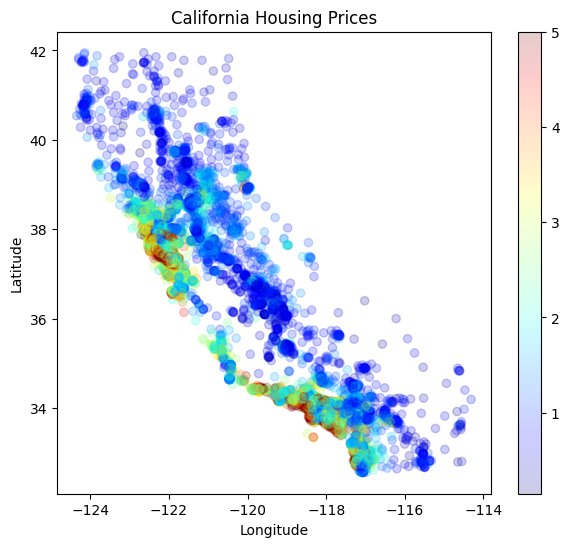

In [3]:
from matplotlib import pyplot as plt

feature_names = housing.feature_names

plt.figure(figsize=(7,6))
plt.scatter(X_train[:, feature_names.index("Longitude")],
            X_train[:, feature_names.index("Latitude")],
            c=y_train,
            cmap="jet", alpha=0.2)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices")
plt.show()

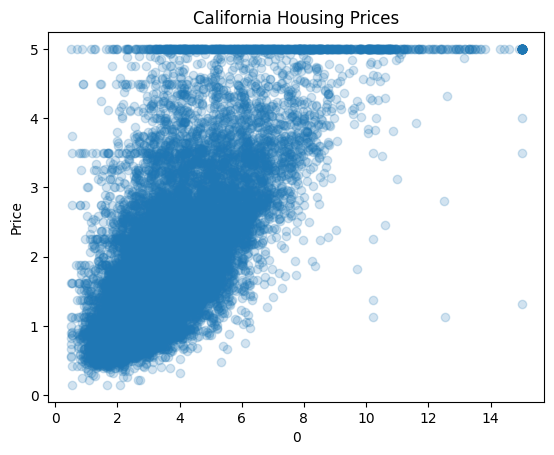

In [5]:
from matplotlib import pyplot as plt

def plot_regression_dataset(X, y, feat_idx=0):
  plt.scatter(X[:, feat_idx],
              y, alpha=0.2)
  plt.xlabel(feat_idx)
  plt.ylabel("Price")
  plt.title("California Housing Prices")

plot_regression_dataset(X_train, y_train, 0)
plt.show()

In [6]:
from matplotlib import pyplot as plt

def plot_predictions(y, y_pred, feature="MedInc"):
  plt.scatter(X_train[:, feature_names.index("MedInc")],
              y_train, alpha=0.2)
  plt.scatter(X_train[:, feature_names.index("MedInc")],
              y_pred, alpha=0.2)
  plt.xlabel(feature)
  plt.ylabel("Price")
  plt.legend(["Actual", "Predicted"])
  plt.title("California Housing Prices")



In [12]:
fakeX = np.arange(12).reshape(3,4)
print(fakeX)
print(fakeX.mean(axis=0))
print(fakeX.std(axis=0))
print((fakeX - fakeX.mean(axis=0)) / fakeX.std(axis=0))

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[4. 5. 6. 7.]
[3.26598632 3.26598632 3.26598632 3.26598632]
[[-1.22474487 -1.22474487 -1.22474487 -1.22474487]
 [ 0.          0.          0.          0.        ]
 [ 1.22474487  1.22474487  1.22474487  1.22474487]]


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regressão Linear Simples

$\hat y = \beta_0 + \beta_1x$



$\beta_0$: intercepto;
$\beta_1$: coeficiênte

0.8362652210005739


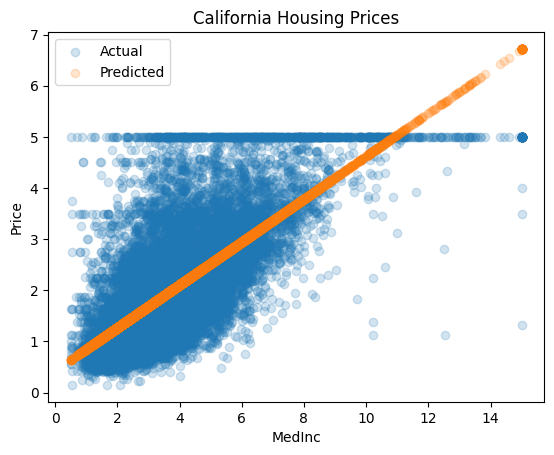

In [47]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import root_mean_squared_error

class SimpleLinearRegression(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=50000, learning_rate=0.0001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    self.intercept_ = 0
    self.coefs_ = np.zeros(shape=(X.shape[1],))
    for i in range(self.max_iter):
      y_pred = self.predict(X)
      error = y - y_pred
      self.intercept_ += np.mean(error) * self.learning_rate
      self.coefs_ += X.T @ error * self.learning_rate
    return self

  def predict(self, X):
    return self.intercept_ + X @ self.coefs_

model = SimpleLinearRegression()
model.fit(X_train_scaled[:,0:1], y_train)
y_pred = model.predict(X_train_scaled[:,0:1])
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

0.7723729237793147


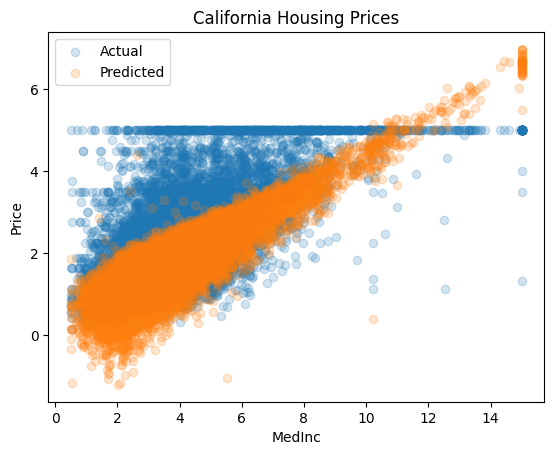

In [61]:
model = SimpleLinearRegression(max_iter=200_000, learning_rate=0.00001)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

0.8543830309266961


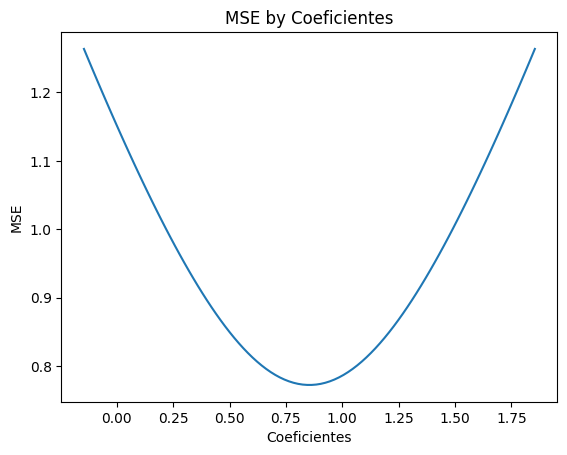

In [64]:
def plot_mse_by_coef(model, X, y, coef_idx):
  mse = []
  coef_idx_value = model.coefs_[coef_idx]
  print(coef_idx_value)
  coefs = np.linspace(model.coefs_[coef_idx] - 1, model.coefs_[coef_idx] + 1, 100)
  for coef in coefs:
    model.coefs_[coef_idx] = coef
    y_pred = model.predict(X)
    mse.append(root_mean_squared_error(y, y_pred))
  model.coefs_[coef_idx] = coef_idx_value
  plt.plot(coefs, mse)
  plt.xlabel("Coeficientes")
  plt.ylabel("MSE")
  plt.title("MSE by Coeficientes")
  plt.show()

plot_mse_by_coef(model, X_train_scaled, y_train, 0)

-0.8698417752425023


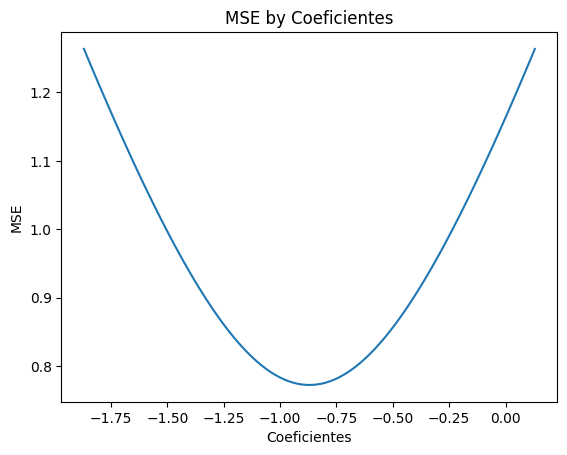

In [66]:
plot_mse_by_coef(model, X_train_scaled, y_train, 7)